Sveučilište u Zagrebu<br/>
Fakultet elektrotehnike i računarstva<br/>
Zavod za elektroničke sustave i obradbu informacija

Akademska školska godina 2025./2026.

**2. vježba: Očitavanje i Fourierova analiza**

*Osnove obradbe signala* (183447, 223374)

Autor: Tomislav Petković

Datum: 2025-10-16

Molimo vas da komentare na ove upute (ispravke, primjedbe, prijedloge itd.) šaljete e-poštom na tomislav.petkovic.jr@fer.unizg.hr.

© Sveučilište u Zagrebu Fakultet elektrotehnike i računarstva, 2025.

Umnažanje i distribucija ovih uputa su dozvoljeni samo ako svaka kopija sadrži gorenavedenu informaciju o autorskim pravima te ovu dozvolu o umnažanju.

# Uvod

Upute za drugu laboratorijsku vježbu iz predmeta *Osnove obradbe signala* su pripremljene u obliku <a href="https://jupyter.org/">Jupyterske</a> bilježnice.

Jupyterska bilježnica koristi <a href="https://ipython.org/">IPython</a> koji je interaktivni interpreter za Pyhton. Uobičajeni način korištenja bilježnice je kroz internetski preglednik. Pri tome preglednik može biti spojen na lokalnu bilježnicu, no isto tako se mogu koristiti udaljene bilježnice koje se izvršavaju na Googleovom Colaboratoryu.

Svi zadaci u ovoj bilježnici su dovoljno jednostavni tako da se mogu riješiti korištenjem <a href="https://colab.research.google.com">Googleovog Colaboratorya</a> (skraćeno Colab).

Svaki softver je samo alat. Sukaldno tome, osim Pythona slobodno smijete koristiti i druge alate kao što su <a href="https://www.mathworks.com/products/matlab.html">Matlab</a>, <a href="https://www.gnu.org/software/octave/index">GNU Octave</a> i <a href="https://www.scilab.org/">Scilab</a> kako bi riješili zadane zadatke. Napominjemo da korištenje drugih alata može značiti da vaš izvještaj s vježbe ne možete predati popunjavanjem ove bilježnice, odnosno da morate pripremiti novi pisani izvještaj, pogotovo ako koristite softver koji se ne može povezati s Jupyterskom bilježnicom. Dodatno, nastavnici vam mogu pomoći oko izrade vježbe samo ako koristite Python ili Matlab.

## Upute za predaju izvještaja s vježbe

Ako rješavate vježbu u Pythonu onda jednostavno upišite vaše odgovore u prazna polja, i to programski kod u polja za kod te odgovore na postavljena pitanja u tekstualna polja.

Prazna polja u koja upisujete programski kod sadrže zadani komentar: `# Upišite vaše rješenje`.

Tekstualna polja u koja morate upisati odgovore na postavljena pitanja sadrže masni tekst napisan velikim tiskanim slovima: **UPIŠITE VAŠ ODGOVOR**.

Jednom kada su svi zadaci riješeni ispunjenu bilježnicu pohranite u datoteku s imenom `JMBAG_IME_PREZIME_Vjezba_2.ipynb` te tu datoteku predajte pod odgovarajuću zadaću u FER-ovom Moodleu.

Predane bilježnice mogu biti automatski re-evaluirane što odgovara naredbi  *Restart Kernel and Run All Cells*. Prema tome, svakako prije predaje vaše bilježnice pokrenite tu naredbu i provjerite ispravnost svih unesenih rješenja.

Ako ste vježbu izradili korištenjem nekog drugog softvera koji nije kompatibilan s Jupyterskom bilježnicom onda morate pripremiti standardni pisani izvještaj s laboratorijske vježbe.

# Podaci o studentu

Molimo vas da prije ispunjavanja ostatka bilježnice dvaput kliknete na ovaj tekst te zatim upište vaše podatke:

Ime: **FRAN GALIĆ**

Matični broj (JMBAG): **0036546889**

Također odmah promijenite ime datoteke u JMBAG_IME_PREZIME_Vjezba_2.ipynb.

# Uvoz potrebnih funkcija

Radi smanjivanja razlika između programskog koda u Pythonu i u Matlabu u ovoj bilježnici ćemo namjerno uvesti sve potrebne funkcije iz <a href="https://www.scipy.org/">SciPy</a>-ja, <a href="https://numpy.org/">NumPy</a>-ja i <a href="https://matplotlib.org/">Matplotlib</a>-a izravno u globalni imenik tako da možemo jednostavno pisati `fft` umjesto punog imena `scipy.fft.fft`.

Imajte u vidu da je ovakav pristup uvjetno prihvatljiv radi pojednostavljenja koda za laboratorijske vježbe jer su rizici kolizije i neočekivanih nuspojava za kratki kod kojeg trebate pripremiti u zadanim zadacima minimalni, no svakako ga je najbolje izbjegavati u praksi. **Uvoz funkcija u globalni imenik se ne koristi u produkcijskom kodu.**

Ako preferirate korištenje imenika i punih imena funkcija onda slobodno izmijenite naredbe za uvoz funkcija tako da sve uvezene funkcije ostanu strogo razdvojene.

In [38]:
import numpy as np
# Uvezi potrebne funkcije u globalni imenik
# numpy mora biti učitan prvi tako da njegove funkcije ne prikriju funkcije iz scipy.signal i scipy.fft
from numpy import *
from scipy.signal import *
from scipy.fft import *
from matplotlib import pyplot as plt

# 1. Očitavanje

U prvom dijelu vježbe razmatramo postupak očitavanja vremenski kontinuiranih signala.

Neka je $x_c(t):\mathbb{R}\to\mathbb{R}$ vremenski kontinuirani signal. Očitavanje signala $x_c(t)$ s periodom očitavanja $T_s>0$ definiramo kao uzimanje vrijednosti signala u trenutcima $t_n=nT_s$ koji defniraju očitani signal $x_d[n]:\mathbb{Z}\to\mathbb{R}$ koji je vremenski diskretan i za kojeg vrijedi
$$x_d[n]=x_c(nT_s).$$
Kako se u obradi signala dogovorno oble zagrade koriste za vremenski kontinuirane nezavisne varijable, a uglate za vremenski diskretne, indekse $c$ i $d$ u $x_c(t)$ i $x_d[n]$ možemo ispustiti pa kraće pišemo $x[n]=x(nT)$.

Ako radimo na računalu onda svaki vremenski kontinuirani signal NE možemo pohraniti kao skup njegovih vrijednosti jer vremenski kontinuirani signali imaju neprebrojivo mnogo vrijednosti, i to bez obzira je li trajanje tog signala ograničeno na konačan interval ili nije. No zato vremenski kontinuirane signale možemo modelirati pomoću podprograma ili funkcije koji računaju vrijednosti signala u nekim odabranim vremenskim trenutcima.

Slično vrijedi i za vremenski diskretne signale neograničenog trajanja koje ne možemo pohraniti kao skup uzoraka jer takvi signali imaju prebrojivo beskonačno vrijednosti odnosno uzoraka, no opet možemo koristiti podprogram ili funkciju koji računaju vrijednost vremenski diskretnog signala beskonačnog trajanja u nekim odabranim diskretnim trenutcima.

Jedine signale koje možemo pohraniti kao skup uzoraka su vremenski diskretni signali konačnog trajanja.

Zato ćemo u ovoj vježbi prvo pripremiti funkcije za računanje vrijednosti signala koje razmatramo, pa ćemo zatim te funkcije koristiti za modeliranje i vizualizaciju procesa očitavanja i rekonstrukcije signala.

## 1.1. Vremenski kontinuirani signali

Ako želimo modelirati vremenski kontinuirane signale na računalu onda moramo pripremiti funkcije koje računaju vrijednosti takvih signala u nekim odabranim trenutcima.

Napišite funkciju koja računa vrijednosti vremenski kontinuiranog sinusoidalnog signala zadanog izrazom $x(t)=A\sin(\Omega t + \varphi)$ u odabranim trenutcima $t_k$ čija deklaracija je:

```
def oos_sin(t, omega = 1, phi = 0, A = 1):
  # ovdje dolazi programski kod za računanje vrijednosti signala x
  return x
```

Ulazni parametri funkcije su niz vremenski trenutaka `t` ($t_k$) koji uvijek mora biti zadan te parametri sinusoide: kružna frekvencija `omega`, faza `phi` i amplituda `A` sa zadanim vrijednostima $\Omega=1$, $\varphi=0$ i $A=1$.

Niz ulaznih trenutaka $t_k$ je dogovorno uvijek uzlazno sortiran bez ponavljajućih vrijednosti, odnosno vrijednosti u nizu trenutaka $t_k$ se monotono povećavaju i vrijedi $t_{k}<t_{k+1}$. Za generiranje takvog niza vremenskih trenutaka uobičajeno se koriste naredbe
[`numpy.arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) u Pyhtonu ili operator
[`:`](https://www.mathworks.com/help/matlab/ref/colon.html) u Matlabu.  

In [39]:
def oos_sin(t: np.ndarray, omega = 1.0, phi = 0.0, A = 1):
    return A * np.sin((omega * t) + phi)

## 1.2. Očitavanje signala

Očitavanje signala je uzimanje vrijednosti signala u odabranim jednoliko razmaknutim vremenskim trenutcima. Radi jednostavnosti u ovoj vježbi pretpostavljamo da očitavanje uvijek započinje od trenutka $t=0$ te da uzastpono očitavamo ukupno $N$ uzoraka, odnosno trenutci očitavanja signala su oblika $t_n=nT_s$ gdje $n=0,1,\ldots N-1$.

Napišite funkciju koja računa $N$ očitanih vrijednosti nekog vremenski kontinuiranog signala zadanog drugom funkcijom čija deklaracija je:

```
def oos_ocitaj(signal, T = 1.0, N = 10):
  # ovdje dolazi programski kod za očitavanja signala i računanje uzoraka x
  return x, t
```

Ulazni parametri funkcije su druga funkcija `signal` koja definira kako računamo vrijednosti vremenski kontinuiranog signala kojeg očitavamo te parametri postupka očitavanja: period očitavanja `T` i broj uzoraka `N` sa zadanim vrijednostima $T_s=1$ i $N=10$. Povratne vrijednosti su vrijednosti očitanih uzoraka `x` i odgovarajući vremenski trenutci očitavanja `t`.

In [40]:
def oos_ocitaj(signal, T = 1.0, N = 10):
    time_ticks = np.arange(N) * T
    return signal(time_ticks), time_ticks

## 1.3. Vizualizacija očitavanja

Prilikom razmatranja procesa očitavanja uobičajeno želimo vizualizirati kako se očitani uzorci ponašaju obzirom na polazni vremenski kontinuirani signal.

To možemo napraviti na način da na istoj slici nacrtamo vremenski kontinuiran signal i njegove očitane uzorke,
gdje za crtanje vremenski kontinuiranog signala koristimo naredbu `plot` odnosno
[`matplotlib.pyplot.plot`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html),
a za crtanje očitanih uzoraka koristimo naredbu `stem` odnosno
[`matplotlib.pyplot.stem`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.stem.html).

Pri tome moramo osigurati da su uzorci vremenski kontinuiranog signala koje prosljeđujemo naredbi `plot` dovoljno gusti u vremenu tako da ne možemo uočiti linearne segmente koji spajaju zadane uzorke. Jedan jednostavni način kako to ostvariti jest da odaberemo koliko dodatnih uzoraka vremenski kontinuiranog signala računamo između svaka dva trenutka očitavanja, npr. možemo izračunati 20 uzoraka vremenski kontinuiranog signala između svaka dva trenutka očitavanja.

Napišite funkciju koja vizualizira očitavanje nekog vremenski kontinuiranog signala zadanog drugom funkcijom u $N$ točaka s periodom očitavanja $T_s$. Neka deklaracija funkcije bude oblika:

```
def oos_vizualiziraj(signal, ime='', T = 0.1, N = 11):
  # ovdje dolazi programski kod za crtanje vremenski kontinuiranog signala i očitanih uzoraka
```

Ulazni parametar `signal` je funkcija koja računa vrijednosti uzoraka vremenski kontinuiranog signala, a `ime` je oznaka nacrtane slike. Parametri očitavanja su period očitavanja `T` i broj uzoraka `N` sa zadanim vrijednostima $T_s=0.1$ i $N=11$. Za postupak očitavanja interno pozovite funkciju `oos_ocitaj` koju ste pripremili u dijelu 1.2. Neka vremenska os za vizualizaciju koristi kontinuirano vrijeme $t$.

Napomena: Primijetite da u vizualizaciji očitavanja postoji slobodan izbor vremenske osi, odnosno može se koristiti kontinuirana vremenska os koja prikazuje kontinuirano vrijeme $t$ ili diskretna vremenska os koja prikazuje korak $n$. Veza između njih je $t=nT$ ili $n=t/T$. Prema tome u tijelu funkcije morate eksplicitno izračunati vrijednosti nezavisne varijable za vremenski kontinuirani i za vremenski diskretni signal za odabranu vremensku os te ih zatim proslijediti naredbama `plot` i `stem`.

In [41]:
def oos_vizualiziraj(signal, ime='', T = 0.1, N = 11):
    con_val_sim, ticks = oos_ocitaj(signal, (T / 20), N * 20)
    dis_val, dis_ticks = con_val_sim[::20], ticks[::20]
    plt.plot(ticks, con_val_sim, c="red")
    plt.stem(dis_ticks, dis_val)
    plt.title(ime)
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.legend(['vremenski kontinuirani signal', 'diskretno očitavanje'], loc='upper right')
    plt.grid(True)
    plt.show()

Korištenjem pripremljenih funkcija sada želimo vizualizirati očitavanja $N=11$ uzoraka tri vremenski kontinuirane sinusoide kružnih frekvencije $2\pi$, $22\pi$ i $42\pi$ s periodom očitavanja $T_s=0.1$.

Nacrtajte polaznu vremenski kontinuiranu sinusoidu te očitane uzorke za sva tri zadana slučaja.

Napomena: Koristite [lambda](https://docs.python.org/3/reference/expressions.html#lambda) izraze za definiciju vremenki kontinuiranog signala `signal` kao ulaznog parametra u funkciju `oos_vizualiziraj`, npr. `lambda t: oos_sin(t, 2.0*pi)` definira sinusoidu frekvencije $2\pi$.

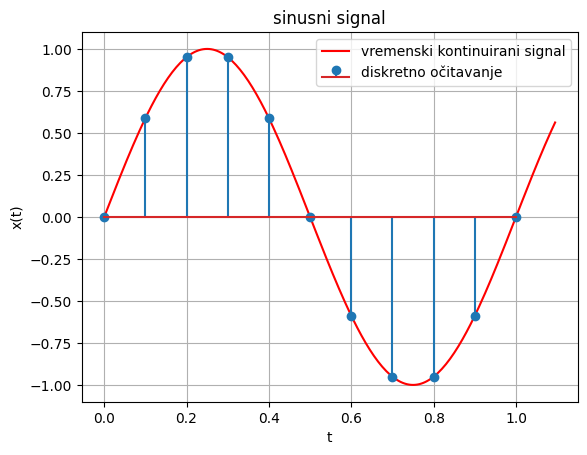

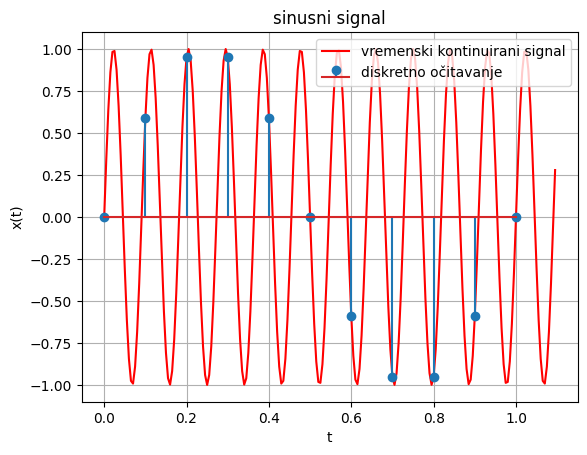

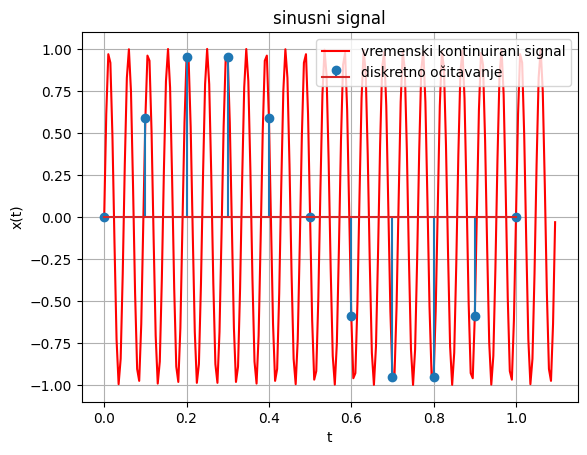

In [42]:
oos_vizualiziraj(lambda t: oos_sin(t, omega=(2 * np.pi)), ime="sinusni signal", T=0.1, N=11)
oos_vizualiziraj(lambda t: oos_sin(t, omega=(22 * np.pi)), ime="sinusni signal", T=0.1, N=11)
oos_vizualiziraj(lambda t: oos_sin(t, omega=(42 * np.pi)), ime="sinusni signal", T=0.1, N=11)

Jesu li vrijednosti očitanih uzoraka sve tri kontinuirane sinusoide kružnih frekvencije $2\pi$, $22\pi$ i $42\pi$ jednake ili nisu?

Vrijednosti očitanih uzoraka za sve tri sinusoide su jednake,
jer se zbog periodičnosti funkcije sinus i prevelike kružne frekvencije (u odnosu na frekvenciju uzorkovanja) događa **aliasing**, više frekvencije se preslikavaju u nižu efektivnu frekvenciju u diskretnom signalu.

Korištenjem pripremljenih funkcija sada želimo vizualizirati očitavanja $N=11$ uzoraka dvije vremenski kontinuirane sinusoide kružnih frekvencije $8\pi$ i $12\pi$ s periodom očitavanja $T_s=0.1$.

Nacrtajte polaznu vremenski kontinuiranu sinusoidu te očitane uzorke za dva zadana slučaja.

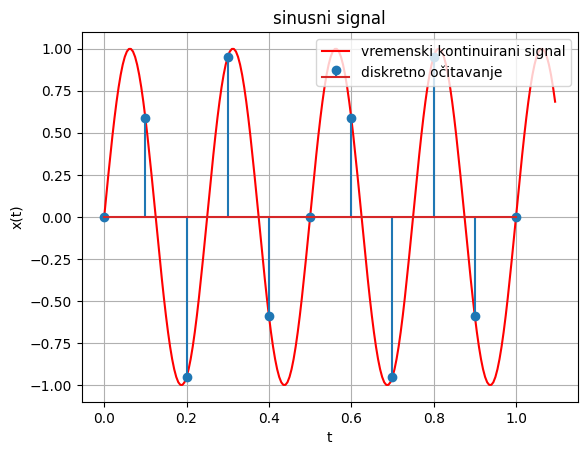

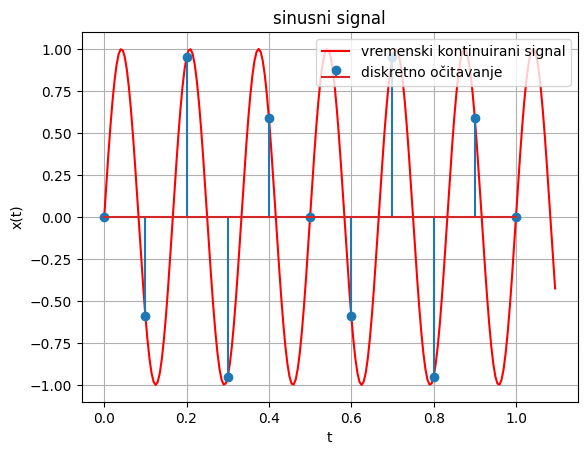

In [43]:
oos_vizualiziraj(lambda t: oos_sin(t, omega=(8 * np.pi)), ime="sinusni signal", T=0.1, N=11)
oos_vizualiziraj(lambda t: oos_sin(t, omega=(12 * np.pi)), ime="sinusni signal", T=0.1, N=11)

Jesu li vrijednosti očitanih uzoraka dvije kontinuirane sinusoide kružnih frekvencije $8\pi$ i $12\pi$ jednake ili nisu?

Vrijednosti očitanih uzoraka nisu iste, ali su po obliku jednake, razlikuju se samo u fazi (jedna je pomaknuta ili „obrnuta“ u odnosu na drugu). Zapravo za cetvrtinu faze.


## 1.4. Višeznačnost vremenski diskretne sinusoide

Povećanje kružne frekvencije $\Omega$ nekog vremenski kontinuiranog sinusoidalnog signala oblika $x(t)=A\sin(\Omega t+\varphi)$ uvijek povećava broj oscilacija sinusoide unutar bilo kojeg konačnog vremenskog intervala, a smanjenje smanjuje, odnosno dvije vremenski kontinuirane sinusoide s različitim kružnim frekvencijama $\Omega_1$ i $\Omega_2$ su signali koji poprimaju različite vrijednosti skoro svuda osim u prebrojivo mnogo točaka u kojima se sijeku.

Isto svojstvo NE vrijedi za vremenski diskretne sinusoide oblika $x[n]=A\sin(\omega n+\varphi)$!

Naime, funkcija $\sin(x)$ je periodična s periodom $2\pi$ pa zatmo možemo pomaknuti argument funkcije sinus za bilo koji cijeli broj perioda. Prema tome ako vremenski diskretnoj sinusoidi pomaknemo argument za $kn$ ($k,n\in\mathbb{Z}$) cijelih perioda funkcije sinus onda vrijedi
$$x_0[n]=A\sin(\omega_0 n+\varphi)=A\sin(\omega_0 n+\varphi+2\pi kn)=A\sin\bigl((\omega_0+2\pi k)n+\varphi\bigr)=A\sin(\omega_k n+\varphi)=x_k[n],$$
odnosno sve diskretne kružne frekvencije oblika $\omega_k=\omega_0+2\pi k$ daju isti niz uzoraka sinusoide.

Ta višeznačnost vremenski diskretnih sinusoida se naziva *aliasing*.

### 1.4.A Različite frekvencije koje daju iste nizove

Za svaku od zadanih kružnih frekvencija vremenski kontinuiranih sinusoide
iz dijela 1.3., dakle za $2\pi$, $22\pi$ i $42\pi$ te za $8\pi$ i $12\pi$,
navedite barem još jednu različitu kružnu frekvenciju koja će nakon očitavanja dati isti vremenski-diskretan niz.

Za Ts = 0.1 s vrijedi ω = Ω·Ts, pa su ω1 = 0.2π, ω2 = 2.2π ≡ 0.2π i ω3 = 4.2π ≡ 0.2π (mod 2π). Sve tri daju isti diskretni niz jer se razlikuju za višekratnik 20π, što se vidi na grafu po tome što su očitani uzorci jednaki (aliasing).

Znači za 2π to može biti i 62π, za 8π može biti i 28π a za 14π može biti i 34π


### 1.4.B Frekvencije sinusoida u protufazi

Rezultat očitavanja dvije vremenski kontinuirane sinusoide
kružnih frekvencija $8\pi$ i $12\pi$ iz dijela 1.3. nije isti niz,
no ipak postoji veza između dobivenih uzoraka. Kako su ti uzorci vezani?

Uzorci sinusoida frekvencija 8π i 12π su međusobno suprotni jer za Ts = 0.1 vrijedi ω1 = 0.8π i ω2 = 1.2π ≡ -0.8π (mod 2π), pa su sinusoide u protufazi i vrijedi x₂[n] = −x₁[n].


### 1.4.C Temeljni interval frekvencija i kritična frekvencija

Ako frekvenciju kontinuirane sinusoide $\Omega$ ograničimo tako da je strogo manja od $\pi/T_s$,
odnosno ako vrijedi $$|\Omega|<\frac{\pi}{T_s},$$ onda se nalazimo unutar jednog intervala
pomaka argumenta vremenski diskretne sinusoide za $nk$ perioda funkcije sinus što nam omogućava da dogovorno
razrješimo višeznačnost diskretne sinusoide tako da od svih mogućih $\omega_k=\omega_0+2\pi k$ odaberemo
jedinstvenu kružnu frekvenciju iz intervala $\langle-\pi,\pi\rangle$.

Graničnu vrijednost $\pi/T_s$ nazivamo kritičnom ili Nyquistovom frekvencijom.

Ako odaberemo $T_s=0.1$ onda je kritična frekvencija $\Omega=10\pi$.

Korištenjem pripremljenih funkcija želimo vizualizirati očitavanja $N=21$ uzorka s periodom očitavanja $T_s=0.1$ tri vremenski kontinuirane sinusoide kritične kružne frekvencije $10\pi$ i faznih pomaka $0$, $\pi/6$ i $\pi/2$. Nacrtajte polaznu vremenski kontinuiranu sinusoidu te očitane uzorke za tri zadana slučaja.

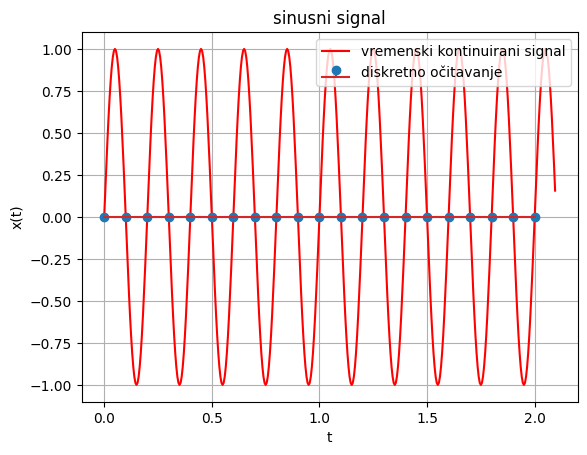

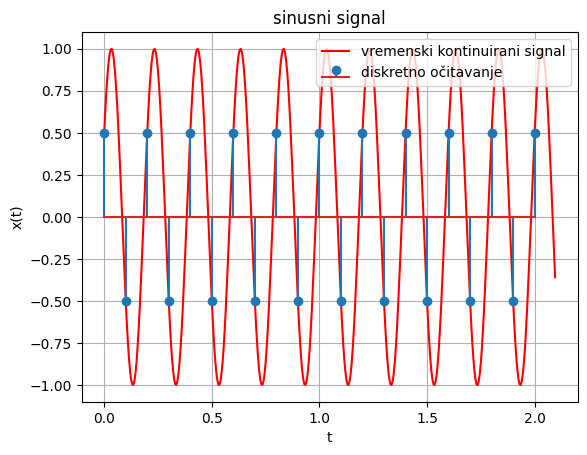

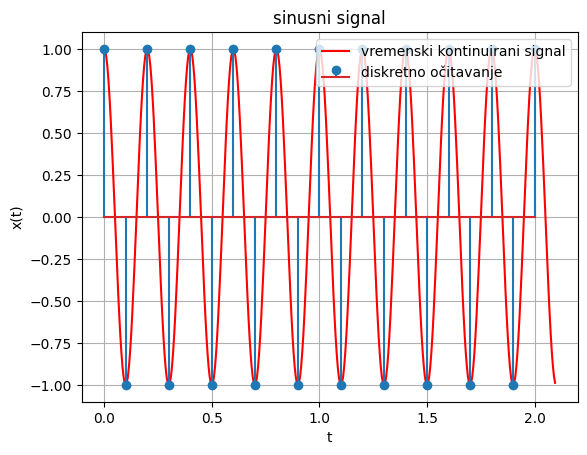

In [44]:
oos_vizualiziraj(lambda t: oos_sin(t, omega=(10 * np.pi), phi=0), ime="sinusni signal", T=0.1, N=21)
oos_vizualiziraj(lambda t: oos_sin(t, omega=(10 * np.pi), phi=(np.pi / 6)), ime="sinusni signal", T=0.1, N=21)
oos_vizualiziraj(lambda t: oos_sin(t, omega=(10 * np.pi), phi=(np.pi / 2)), ime="sinusni signal", T=0.1, N=21)

Je li iz dobivenih uzoraka moguće jednoznačno rekonstruirati sinusoidu kritične frekvencije? Ukratko objasnite!

Ne, nije moguće jednoznačno rekonstruirati sinusoidu na kritičnoj frekvenciji jer za ω=π vrijedi x[n]=A(−1)ⁿsin(φ). Uzorci ovise samo o umnošku A·sin(φ), pa različite kombinacije amplitude i faze daju isti diskretni niz, što znači da se gubi informacija o fazi (aliasing na Nyquistovoj granici).

## 1.5. Periodičnost vremenski diskretnih signala

Vremenski diskretan signal $x[n]$ je periodičan ako postoji cijeli broj $P$ različit od nule takav da vrijedi
$$x[n]=x[n+P].$$
Najmanji pozitivni $P$ za koji to vrijedi se naziva temeljni period.

Vremenski diskretna sinusoida oblika
$$x[n]=A\sin\bigl(\omega n + \varphi\bigr)$$
je periodična samo za određene vrijednosti kružne frekvencije $\omega$ za koje jednadžba
$$x[n]=A\sin\bigl(\omega n + \varphi\bigr)=A\sin\bigl(\omega (n+P) + \varphi\bigr)=x[n+P]$$
ima netrivijalno cjelobrojno rješenje u $P$.

### 1.5.A Uvjet periodičnosti vremenski diskretne sinusoide

Navedite uvjet kojeg kružna frekvencija $\omega$ mora zadovoljiti
da vremenski diskretna sinusoida $x[n]=A\sin\bigl(\omega_0 n + \varphi\bigr)$ bude periodična.

Uputa: Dovoljno je upisati uvjet, odnosno nije potrebno prepisivati cijeli postupak.
Do traženog uvjeta možete doći rješavanjem pojednostavljene jednadžbe $\sin(\omega n)=\sin\bigl(\omega (n+P)\bigr)$ na papiru.


ODGOVOR:
Diskretna sinusoida je periodična ako je omjer ω / 2π racionalan broj, tj. ω = 2π·(k / N) za cijele brojeve k i N.

Ako ω / 2π nije racionalan, faza se nikad ne ponavlja točno nakon konačnog broja uzoraka, pa signal nije periodičan.

### 1.5.B Ispitvanje periodičnosti vremenski diskretne sinusoide

Zadane su dvije vremenski diskretne sinusoide $x_1[n]=\sin(\frac{1}{10}\pi n)$ i $x_2[n]=\sin(\sqrt{2}\pi n)$. Nacrtajte prvih $N=100$ uzoraka obje sinusoide u dvije odvojene slike.

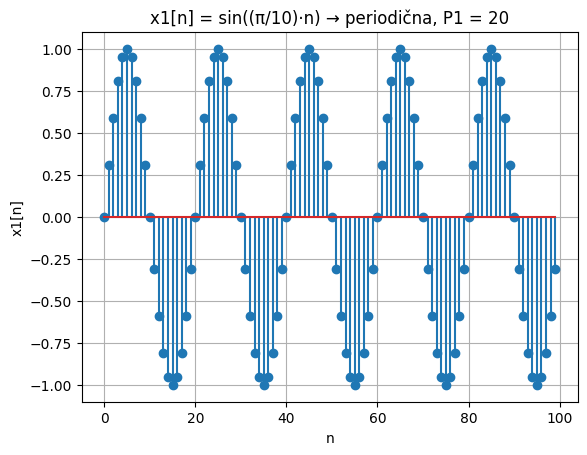

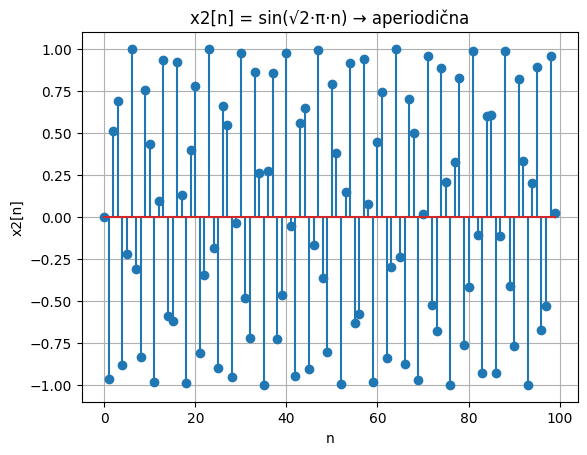

In [45]:
def oos_sin_dis(n, omega, phi=0.0, A=1.0):
    return A * np.sin(omega * n + phi)

N = 100
n = np.arange(N)

omega1 = np.pi / 10
omega2 = np.sqrt(2) * np.pi

x1 = oos_sin_dis(n, omega1)
x2 = oos_sin_dis(n, omega2)

plt.stem(n, x1)
plt.title("x1[n] = sin((π/10)·n) → periodična, P1 = 20")
plt.xlabel("n"); plt.ylabel("x1[n]"); plt.grid(True)
plt.show()

plt.stem(n, x2)
plt.title("x2[n] = sin(√2·π·n) → aperiodična")
plt.xlabel("n"); plt.ylabel("x2[n]"); plt.grid(True)
plt.show()


Ispitajte postoje li temeljni periodi $P_1$ i $P_2$ prethodno razmatranih vremenski diskretnih sinusoida $x_1[n]=\sin(\frac{1}{10}\pi n)$ i $x_2[n]=\sin(\sqrt{2}\pi n)$ čije kružne frekvencije su $\omega_1=\frac{1}{10}\pi$ i $\omega_2=\sqrt{2}\pi$, i ako postoje onda izračunajte njihovu vrijednost.

Uputa: Zadatak slobodno riješite na papiru, a ovdje upišite samo konačno rješenje. Također, periodičnost ili aperiodičnost dodatno provjerite na slici koju se nacrtali ranije.

Za ω₁ = π/10 vrijedi da je ω₁ / 2π = 1/20 pa je signal periodičan s temeljnim periodom P₁ = 20.
Za ω₂ = √2·π vrijedi da je ω₂ / 2π = √2/2 iracionalan broj pa signal nije periodičan (aperiodičan je).



# 2. Interpolacija i teorem očitavanja

Kod očitavanja vremenski kontinuiranog signala $x(t)$ s periodom očitavanja $T_s$
nužno dolazi do gubitka informacije.
Zato je od interesa postaviti neka ograničenja na polazni vremenski kontinuirani signal $x(t)$
tako da postane moguće rekonstruirati vremenski kontinuirani signal iz njegovih uzoraka.
Jedno od tih ograničenja postavlja teorem očitavanja:

#### Teorem očitavanja

Neka je $x(t)$ vremenski kontinuirani signal i neka je $T_s>0$ pozitivan broj kojeg zovemo period očitavanja. Defniramo red
$$\hat x(t)=\sum\nolimits_{n\in\mathbb{Z}}x(nT_s)\mathop{\rm sinc}\Bigl(\frac{t}{T_s}-n\Bigr).$$
Ako je $x(t)$ pojasno ograničen signal s maksimalnom frekvencijom $\Omega_{\text{MAX}}$ i ako je $T_s<\pi/\Omega_{\text{MAX}}$ onda vrijedi
$$\hat x(t)=x(t).$$

## 2.1. Idealna interpolacija

Sukladno teoremu očitavanja vremenski kontinurani signal možemo rekonstruirati
iz njegovih uzoraka korištenjem funkcije sinc kao interpolacijske funkcije.

Takvu interpolaciju nazivamo idealnom interpolacijom pojasno ograničenog signala.

Napišite funkciju koja računa vrijednosti idealno interpoliranog pojasno ograničenog signal sa sljedećom deklaracijom:

```
def oos_sincinterp(t, n, xd, T=1.0):
  # ovdje dolazi programski kod za računanje interpoliranog signala
  return xc
```

Ulazni parametar `t` je niz vremenskih trenutaka u kojima je potrebno izračunati vrijednost interpolirane funkcije, ulazni parametri `n` i `xd` su dva niza jednakih duljina u kojem prvi sprema vrijednost koraka $n$ a drugi vrijednost očitanog signala $x[n]$, a `T` je period očitavanja.

Uputa: Potrebno je implementirati numeričko računanje izraza
$$x_c(t)=\sum\nolimits_{n}x_d[n]\mathop{\rm sinc}\Bigl(\frac{t}{T_s}-n\Bigr),$$
pri čemu se vrijednosti funkcije sinc računaju korištenjem
[scipy.special.sinc](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.sinc.html#scipy.special.sinc) u Pythonu ili
[sinc](https://www.mathworks.com/help/signal/ref/sinc.html) u Matlabu.

Napomena: Većina programskih biblioteka ne sadrži gotovu funkciju za idealnu interpolaciju jer ista nije ni efikasna ni kauzalna pa se ne koristi često. Naime, funkcija sinc trne proporcionalno s $1/t$ kada $t\to\pm\infty$ što je sporo prigušenje pa zbog toga svaki uzorak $x[n]$ značajno utječe na (skoro) svaku vrijednost izlaznog interpoliranog vremenski kontinuiranog signala $x(t)$ pa je postupak neefikasan. Osim toga, funkcija sinc nema konačnu potporu (razlitiča je od nule za skoro svaki trenutak $t$) pa nije kauzalna što znači da idealnu interpolaciju ne možemo raditi u stvarnom vremenu, već samo na snimljenim signalima konačnog trajanja.

In [46]:
from scipy.special import sinc

def oos_sincinterp(t, n, xd, T=1.0):
    t  = np.asarray(t,  dtype=float)
    n  = np.asarray(n,  dtype=float)
    xd = np.asarray(xd, dtype=float)

    U = (t[:, None] / T) - n[None, :]
    W = sinc(U)
    xc = W @ xd
    return xc

## 2.2. Idealna interpolacija sinusoide

Zadana je vremenski kontinuirana sinusoida $x(t)=\sin(t)$.

Neka je period očitavanja $T=0.3$ te neka je broj uzoraka $67$.

Vizualizirajte očitavanje zadane sinusoide, zatim izračunajte idealnu interpolaciju na intervalu $[0,20]$ u 400 točaka (korak interpolacije 0.05) te nacrtajte rezultat interpolacije.

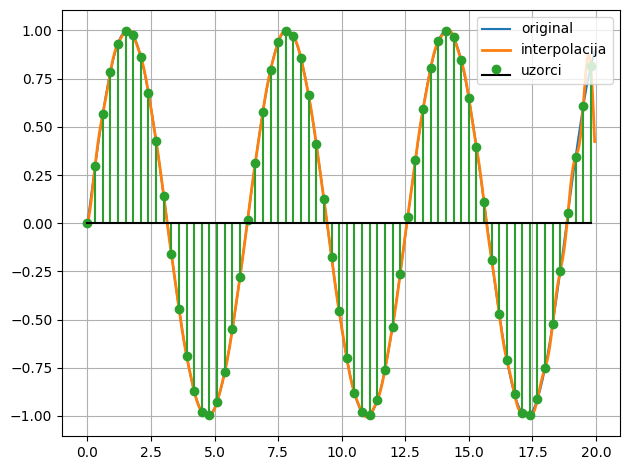

In [47]:
T, N = 0.3, 67
n = np.arange(N)
t_s, xd = n*T, np.sin(n*T)
t = np.arange(0, 20, 0.05)
xc = oos_sincinterp(t, n, xd, T)

plt.plot(t, np.sin(t), label="original")
plt.plot(t, xc, label="interpolacija", linewidth=2)
plt.stem(t_s, xd, linefmt="C2-", markerfmt="C2o", basefmt="k-", label="uzorci")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

# 3. Fourierova analiza

U Fourierovoj analizi signal prikazujemo preko kompleksnih eksponencijalnih funkcija.

Za kvadratno integrabilne vremenski kontinuirane signale beskonačnog trajanja koristimo eksponencijale $\phi_\Omega(t)=\exp(j\Omega t)$ te pripadnu transformaciju zovemo vremenski kontinuiranom Fourierovom transformacijom ili CTFT-om (od engl. *Continuous-Time Fourier Transform*). Vrijedi:

$$\begin{align}
X_c(\Omega)=\bigl\langle x_c(t),\phi_\Omega(t)\bigr\rangle&=\int_{-\infty}^{+\infty}x_c(t)e^{-j\Omega t}\,dt\\
x_c(t)&=\frac{1}{2\pi}\int_{-\infty}^{+\infty}X_c(\Omega)e^{j\Omega t}\,d\Omega\end{align}$$

Za kvadratno sumabilne vremenski diskretne signale beskonačnog trajanja koristimo eksponencijale $\phi_\omega[n]=\exp(j\omega n)$ te pripadnu transformaciju zovemo vremenski diskretnom Fourierovom transformacijom ili DTFT-om (od engl. *Discrete-Time Fourier Transform*). Vrijedi:

$$\begin{align}
X_d(\omega)=\bigl\langle x_d[n],\phi_\omega[n]\bigr\rangle&=\sum_{n=-\infty}^{+\infty}x_d[n]e^{-j\omega n}dt\\
x_d[n]&=\frac{1}{2\pi}\int_{-\pi}^{+\pi}X_d(\omega)e^{j\omega n}\,d\omega\end{align}$$

Kažemo da signali $x_c(t)$ i $x_d[n]$ imaju spektre $X_c(\Omega)$ i $X_d(\omega)$ koji mjere doprinos kompleksnih eksponencijala $\phi_\Omega(t)$ i $\phi_\omega[n]$ u signalu.

Kako su i CTFT i DTFT definirani za signale beskonačnog trajanja na računalu koristimo podprograme ili funkcije koje (približno) numerički računaju vrijednosti pripadnih spektara za zadane ulazne signale.

## 3.1. Vremenski diskretna Fourierova transformacija

Neka je $x[n]$ vremenski diskretni signal konačnog trajanja ili duljine $N$ definiran za $n=0,\ldots,N-1$.

Napišite funkciju koja numerički računa vrijednosti od $\text{DTFT}\bigl[x[n]\bigr]$ u $K$ zadanih frekvencija $\omega_k\in\langle 0,2\pi\rangle$, $k=0,\ldots,K-1$, dekalaracijom oblika:

```
def oos_dtft(x, omega):
  # ovdje dolazi kod za računanje uzoraka DTFT-a
  return X
```

Pri tome je `x` zadani niz uzoraka za koje numerički računamo vrijednosti spektra signala na frekvencijama zadanim nizom `omega` ($\omega_k$).

Uputa: Kako signal $x[n]$ ima konačno trajanje potrebno je $K$ puta numerički izračunati konačan zbroj
$$X(\omega_k)=\sum_{n=0}^{N-1}x[n]e^{-j\omega_k n}.$$

In [48]:
def oos_dtft(x, omega):
    n = np.arange(len(x))              # indeksi n = 0, 1, ..., N-1
    X = np.zeros(len(omega), dtype=complex)
    for k in range(len(omega)):
        X[k] = np.sum(x * np.exp(-1j * omega[k] * n))
    return X

## 3.2. Očitavanje spektra

Numeričko računanje spektra u proizvoljno zadanih $K$ frekvencija $\omega_k\in\langle 0,2\pi\rangle$,
$k=0,\ldots,K-1$, nije numerički efikasno.

Očekivana složenost naivne implementacije je $O(NK)$, gdje je $N$ broj uzoraka ulaznog signala i $K$ broj frekvencija na kojima računamo spektar.

Radi pojednostavljenja postupka zadane frekvencije $\omega_k$ se uobičajeno jednoliko raspoređuju po cijelom intervalu frekvencija $\langle 0,2\pi\rangle$ što odgovara očitavanju spektra.

Prema tome, ako razmatramo vremenski diskretan signal konačnog trajanja od $N$ uzoraka za kojeg želimo numerički izračunati vrijednosti DTFT transformacije u $K$ jednoliko raspoređenih frekvencija oblika $\omega_k=\tfrac{2\pi}{K}k$ onda računamo
$$X(\omega_k)=X\bigl(\tfrac{2\pi}{K}k\bigr)=\sum_{n=0}^{N-1}x[n]e^{-j\omega_k n}=\sum_{n=0}^{N-1}x[n]e^{-j\frac{2\pi}{K}kn}=X[k].$$

Kako se prostor signala duljine $N$ može razapeti s $N$ baznih signala moramo odabrati $K\ge N$ jer u protivnom ne možemo reprezentirati signal zbog nedovoljnog broja baznih signala. Zbog efikanosti često biramo najmanji $K=N$.

Izraz za računanje uzoraka spektra tada postaje
$$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j\frac{2\pi}{N}kn}.$$

Također vrijedi
$$X(\omega)=\sum_{k}X[k]\delta\bigl(\tfrac{N}{2\pi}\omega-k\bigr),$$
te je
$$x[n]=\frac{1}{2\pi}\int_{-\pi}^{+\pi}\Bigl(\sum_{k}X[k]\delta\bigl(\tfrac{N}{2\pi}\omega-k\bigr)\Bigr)e^{j\omega n}\,d\omega
=\frac{1}{2\pi}\sum_{k=0}^{N-1}X[k]\Bigl(\int\delta\bigl(\tfrac{N}{2\pi}\omega-k\bigr)e^{j\omega n}\,d\omega\Bigr)={1\over N}\sum_{k=0}^{N-1}X[k]e^{j\frac{2\pi}{K}kn},$$
što je izraz koji odgovara diskretnoj Fourierovoj transformaciji.

Napišite funkciju za računanje spektra u $K$ jednoliko razmaknutih frekvencija s dekalaracijom oblika:

```
def oos_dtft_jednoliko(x, K):
  # ovdje dolazi kod za računanje uzoraka DTFT-a
  return X
```

Pri tome je `x` zadani niz uzoraka za koje numerički računamo vrijednosti spektra signala na $K$ frekvencija oblika $\omega_k=\tfrac{2\pi}{K}k$. Za računanje koristite pripremljenu funkciju `oos_dtft` kojoj prosljeđujete odgovarajući niz frekvencija `omega`. Ako je $K\ge N$ onda u `oos_dtft` proslijedite niz `x` bez promjena, no ako je $K<N$ onda proslijedite podrezani niz `x` na prvih `K` uzoraka i ispište upozorenje da je niz podrezan (jer ako je $K<N$ onda nemamo dovoljno baznih signala za predstavljanje signala duljine $N$).

In [49]:
def oos_dtft_jednoliko(x, K):
    N = len(x)
    if K < N:
        print("Upozorenje: niz je podrezan jer je K < N")
        x = x[:K]
    omega = 2 * np.pi * np.arange(K) / K
    X = oos_dtft(x, omega)
    return X

## 3.3. Diskretna Fourierova transformacija

Diskretna Fourierova transformacija (DFT) u $N$ točaka je standardni alat koji se koristit za analizu signala konačnog trajanja na računalu i čija značajna prednost jest postojanje algoritma za efikasno računanje. 

DFT u $N$ točaka vremenski diskretnog signala $x[n]$ konačne duljine od $N$ uzoraka jest
$$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j\tfrac{2\pi}{N}nk}=\sum_{n=0}^{N-1}x[n]W_N^{nk},$$
gdje je $X[k]$ spektar signala i gdje je
$$W_N^{nk}=\exp\Bigl(-2\pi j{nk\over N}\Bigr)$$
pokrata zapisa kompleksne eksponencijale.

Signal rekonstruiramo iz njegovog spektra korištenjem izraza
$$x[n]=\frac{1}{N}\sum_{k=0}^{N-1}X[k]e^{j\frac{2\pi}{N}nk}=\frac{1}{N}\sum_{k=0}^{N-1}X[k]W_N^{-nk}.$$

Oba navedena izraza se mogu izračunati izravno prema formuli uz složenost $O(N^2)$ u broju operacija množenja i zbrajanja, no ako koristimo algoritam brze Fourierove transformacije onda nam posebna struktura transformacijske matrice pridružene DFT-u omogućava efikasnije računanje uz složenost $O(N\log N)$.

Brza Fourierova transformacija je dostupna u SciPyju u modulu [`scipy.fft`](https://docs.scipy.org/doc/scipy/reference/fft.html) i u Matlabu. Oba alata koriste ista imena funkcija: `fft` se koristi za računanje DFT-a, a `ifft` se koristi za računanje inverznog DFT-a. Puna imena funkcija u SciPyju su [`scipy.fft.fft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fft.html) i [`scipy.fft.ifft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.ifft.html). Želite li znati više svakako usporedite tu dokumentaciju s Matlabovom dokumentacijom za [`fft`](https://www.mathworks.com/help/matlab/ref/fft.html) i [`ifft`](https://www.mathworks.com/help/matlab/ref/ifft.html).

Funkcijski poziv `fft(x, K)` računa isto što i funkcija `oos_dtft_jednoliko(x, K)`
koju ste pripremili u dijelu 3.2. pa ga možemo koristiti za kontrolu napisane funkcije.

Neka je ulazni signal $x[n]=\{\underline{1},2,3,4\}$.

Pozovite funkcije `fft(x, K)` i `oos_dtft_jednoliko(x, K)` za zadani signal $x$ za $K=4$ (uobičajeno korištenje), $K=5$ (finije računanje spektra) i $K=3$ (nedovoljno baznih funkcija) te usporedite izlazne vrijednosti korištenjem funkcije [`numpy.allclose`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html).

In [50]:
from scipy.fft import fft

x = np.array([1, 2, 3, 4], dtype=float)

for K in (4, 5, 3):
    X_fft  = fft(x, K)
    X_oos  = oos_dtft_jednoliko(x, K)
    print(f"K={K}: allclose ->", np.allclose(X_fft, X_oos),
          "| max |diff| =", np.max(np.abs(X_fft - X_oos)))

K=4: allclose -> True | max |diff| = 1.9860273225978185e-15
K=5: allclose -> True | max |diff| = 2.808666774861361e-15
Upozorenje: niz je podrezan jer je K < N
K=3: allclose -> True | max |diff| = 2.401779625492033e-15


Jesu li rezultati funkcija  `fft(x, K)` i `oos_dtft_jednoliko(x, K)` dovoljno pribiližno jednaki?

Da jesu, što je i očekivano

## 3.4. Amplitudni i fazni spektar

Jednom kada su izračunate vrijednosti spektra želimo ih vizualizirati.

Spektri dobiveni Fourierovim transformacijama su kompleksne funkcije realne varijable pa uobičajeno posebno crtamo amplitudni i posebno fazni spektar.

Amplitudni spektar možemo izračunati korištenjem funkcije `abs` u NumPyju i u Matlabu (primijetite da je `abs` skraćeni poziv funkcije [`numpy.absolute`](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html)).

Fazni spektar je argument ili kut kompleksnog broja koji može biti izračunat korištenjem funkcije `angle`. Puno ime funkcije u NumPyju jest [`numpy.angle`](https://numpy.org/doc/stable/reference/generated/numpy.angle.html), usporedite tu funkciju s Matlabovom [`angle`](https://www.mathworks.com/help/matlab/ref/angle.html). Standardna funkcija `angle` računa kut kompleksnog broja unutar temeljnog intervala $\langle-\pi,\pi\rangle$ i pri tome ne premata fazu kako bi smanjila broj faznih skokova od $2\pi$ kada prelazimo kut $\pm\pi$. Kako bi odmotali fazu i smanjili broj faznih skokova koristite funkciju `unwrap` u NumPyju ([`numpy.unwrap`](https://numpy.org/doc/stable/reference/generated/numpy.unwrap.html)) i u Matlabu ([`unwrap`](https://www.mathworks.com/help/matlab/ref/unwrap.html)).

Također možemo izračunati realni i imaginarni dio spektra korištenjem funkcija  `real` i `imag`. Puna imena tih funkcija u NumPyju su [`numpy.real`](https://numpy.org/doc/stable/reference/generated/numpy.real.html) i [`numpy.imag`](https://numpy.org/doc/stable/reference/generated/numpy.imag.html).

Napišite dvije funkcije za vizualizaciju Fourierovog spektra za DTFT i DFT transformacije koje kao ulazni parametar primaju signal i broj uzoraka u kojima je potrebno računati spektar. Deklaracije neka budu oblika:

```
def oos_dtft_spektar(x, K, ime=''):
  # ovdje dolazi kod za računanje i crtanje DTFT spektra  
```

```
def oos_dft_spektar(x, N, ime=''):
  # ovdje dolazi kod za računanje i crtanje DFT spektra  
```

Obje funkcije kao obavezne ulazne argumente primaju signal i broj uzoraka u kojima se računa spektar, te ime slike kao neobavezni argument.

Potrebno je nacrtati amplitudni spektar, fazni spektar, realni dio kompleksnog spektra i imaginarni dio kompleksnog spektra unutar jedne slike, i to amplitudni i fazni spektar jedan iznad drugog lijevo, te realni i imaginarni dio spektra jedan iznad drugog desno. Za pozicioniranje koristite funkciju
[`matplotlib.pyplot.subplot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html). Spektre za DFT crtajte naredbom `stem`, a izračunate uzorke DTFT spektara crtajte naredbom `plot`. Također primijetite da frekvencijska os za DTFT prikazuje frekvenciju $\omega$, dok za DFT frekvencijska os prikazuje indeks $k$.

Radi efikasnosti u ovim funkcijama slobodno koristite `fft` umjesto `oos_dtft_jednoliko`.

In [51]:
def oos_dtft_spektar(x, K, ime=''):
    omega = 2 * np.pi * np.arange(K) / K
    X = fft(x, K)

    plt.figure(figsize=(10,5))

    plt.subplot(2, 2, 1)
    plt.plot(omega, np.abs(X))
    plt.title('Amplitudni spektar')
    plt.xlabel('ω'); plt.ylabel('|X(ω)|'); plt.grid()

    plt.subplot(2, 2, 3)
    plt.plot(omega, np.unwrap(np.angle(X)))   # faza odmotana
    plt.title('Fazni spektar')
    plt.xlabel('ω'); plt.ylabel('∠X(ω) [rad]'); plt.grid()

    plt.subplot(2, 2, 2)
    plt.plot(omega, np.real(X))
    plt.title('Realni dio spektra')
    plt.xlabel('ω'); plt.ylabel('Re{X(ω)}'); plt.grid()

    plt.subplot(2, 2, 4)
    plt.plot(omega, np.imag(X))
    plt.title('Imaginarni dio spektra')
    plt.xlabel('ω'); plt.ylabel('Im{X(ω)}'); plt.grid()

    plt.suptitle(f"DTFT spektar {ime}")
    plt.tight_layout()
    plt.show()


def oos_dft_spektar(x, N, ime=''):
    X = fft(x, N)
    k = np.arange(N)

    plt.figure(figsize=(10,5))

    plt.subplot(2, 2, 1)
    plt.stem(k, np.abs(X))
    plt.title('Amplitudni spektar')
    plt.xlabel('k'); plt.ylabel('|X[k]|'); plt.grid()

    plt.subplot(2, 2, 3)
    plt.stem(k, np.unwrap(np.angle(X)))
    plt.title('Fazni spektar')
    plt.xlabel('k'); plt.ylabel('∠X[k] [rad]'); plt.grid()

    plt.subplot(2, 2, 2)
    plt.stem(k, np.real(X))
    plt.title('Realni dio spektra')
    plt.xlabel('k'); plt.ylabel('Re{X[k]}'); plt.grid()

    plt.subplot(2, 2, 4)
    plt.stem(k, np.imag(X))
    plt.title('Imaginarni dio spektra')
    plt.xlabel('k'); plt.ylabel('Im{X[k]}'); plt.grid()

    plt.suptitle(f"DFT spektar {ime}")
    plt.tight_layout()
    plt.show()

## 3.5. DFT, DTFT i spektralna analiza

Zadan je signal $x[n]=\{\underline{1},1,0,0.5\}$ konačne duljine od $N=4$ uzorka.

Iskoristite funkcije iz prethodnog dijela 3.4. da izračunate i vizualizirajte sljedeće spektre:

1. $X_1[k]=\text{DFT}_{4}\bigl[x[n]\bigr]$ (DFT transformacija u 4 točke signala od 4 uzorka),
2. $X_2[k]=\text{DFT}_{16}\bigl[x[n]\bigr]$ (DFT transformacija u 16 točaka signala od 4 uzorka),
3. $X_3[k]=\text{DFT}_{128}\bigl[x[n]\bigr]$ (DFT transformacija u 128 točaka signala od 4 uzorka), i
4. $X_4(\omega)=\text{DTFT}\bigl[x[n]\bigr]$ uzorkovan u jednoliko raspodijeljenih $K=1024$ frekvencija.

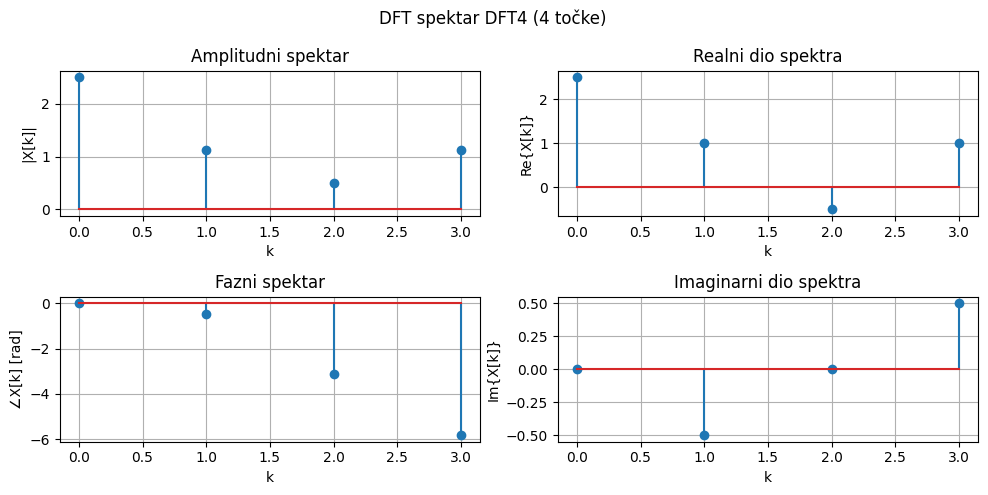

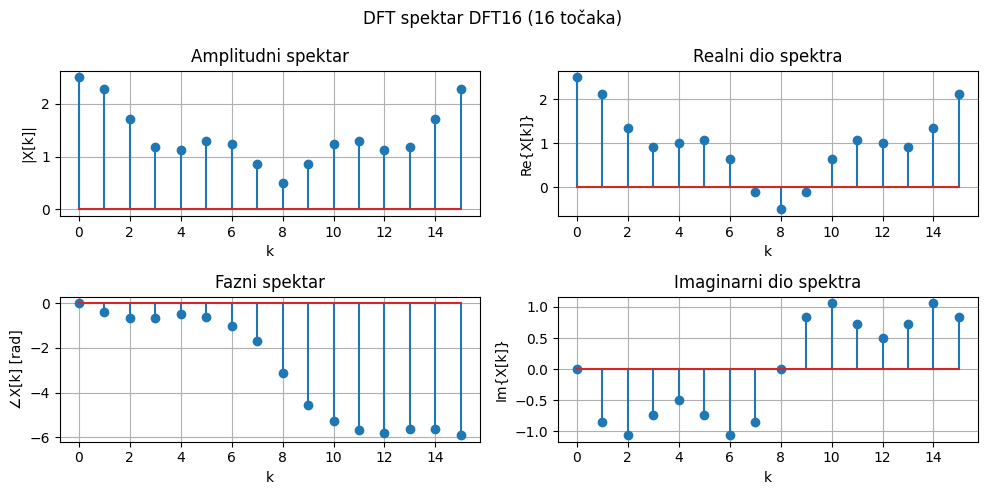

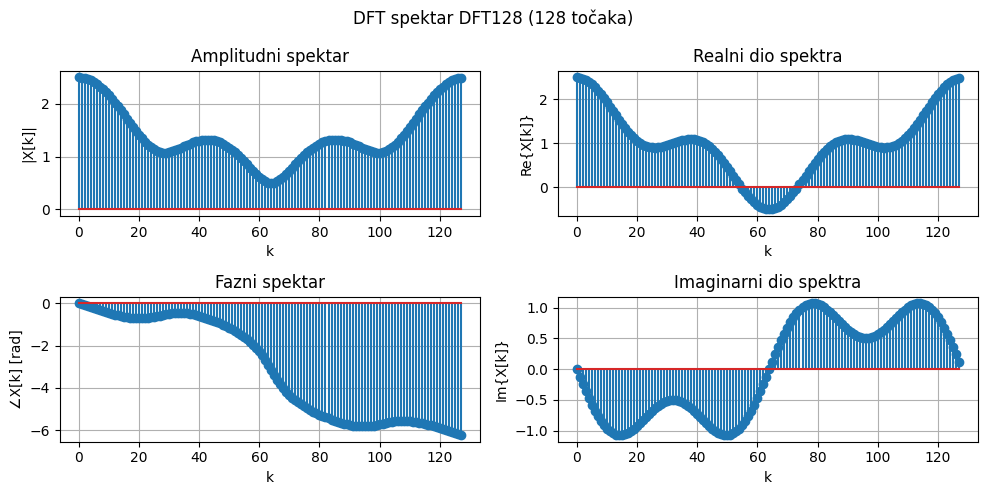

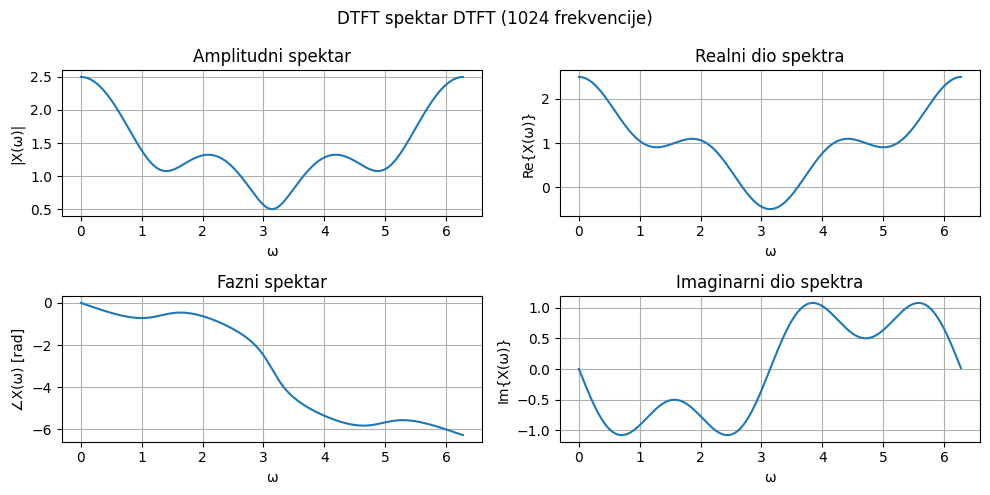

In [52]:
x = np.array([1, 1, 0, 0.5], dtype=float)

oos_dft_spektar(x, 4, ime='DFT4 (4 točke)')
oos_dft_spektar(x, 16, ime='DFT16 (16 točaka)')
oos_dft_spektar(x, 128, ime='DFT128 (128 točaka)')
oos_dtft_spektar(x, 1024, ime='DTFT (1024 frekvencije)')

Koja je veza spektara $X_1[k]$, $X_2[k]$, $X_3[k]$ i $X_4(\omega)$?

Svi spektri prikazuju isti Fourierov spektar signala, ali s različitom razlučivošću.
X1[k], X2[k] i X3[k] su DFT-ovi s različitim brojem točaka (4, 16, 128) koji uzorkuju isti DTFT,
dok je X4(ω) kontinuirana, glađa verzija tog istog spektra.
Povećanjem broja točaka K, DFT se sve više približava DTFT-u.

# 4. Razmazivanje spektra (neobavezno)

**Ovaj dio vježbe nije obavezan; riješite ga ako želite znati više.**

Usporedimo li izračunati DFT spektar segmenta konačnog trajanja nekog signala sa očekivanim DTFT spektrom idealnog signala vrlo brzo uočavamo da izračunati DFT spektar sadrži spektralne komponente kojih nema u DTFT spektru.

Ta razlika u spektrima je uzrokovana *skraćivanjem* trajanja signala na neki *konačan interval*, i nešto je što ne možemo izbjeći u praksi jer računala mogu raditi samo sa signalima konačne duljine.

Takvo skraćivanje možemo modelirati kao množenje signala $x[n]$ s pravokutnim vremenskim otvorom $w_L[n]$, odnosno $$x_L[n]=x[n]\cdot w_L[n],$$ gdje je vremenski otvor funkcija koja odabire prvih $L$ uzoraka signala od $0$ do $L-1$ te koja sve ostale uzorke postavlja u nulu. U spektralnoj domeni ova operacija množenja postaje konvolucija između odgovarajućih spektara, dakle $$X_L(\omega)=X(\omega)*W_L(\omega).$$ Tu konvoluciju možemo interpretirati kao razmazivanje idealnog spektra sukladno obliku spektra vremenskog otvora jer je konačni efekt da spektar signala gubi svoju oštrinu. U općem slučaju spektar je oštriji što je duljina vremenskog otvora $L$ veća. U graničnom slučaju kada $L\to\infty$ vremenski otvor $w_L[n]$ postaje jedinična konstanta, $w_L[n]=1$. Spektar jedinične konsntate jest Diracova distribucija $\delta(\omega)$ koja je neutralni element za konvoluciju, odnosno $X(\omega)*\delta(\omega)=\delta(\omega)*X(\omega)=X(\omega)$, te nema gubitka oštrine.

## 4.A Generiranje segmenta vremenski diskretne kosinusoide

Neka je $x[n]=\cos(2\pi{m\over P}n)$ periodična vremenski diskretna kosinusoida s periodom $P$ te neka je $m$ cijeli broj za koji vrijedi $0\le m\le {P\over2}-1$. Napišite funkciju koja generira niz od $L$ uzoraka signala za zadane parametre $m$ i $P$.

In [53]:
# Upišite vaše rješenje

## 4.B Spektar vremenski diskretne periodične kosinusoide

Neka je $P=L=N=10$ ($N$ je broj uzoraka ili duljina DFT-a).

Korištenjem funkcija iz zadatka 4.A generirajte signale za m=2 i za m=5. Zatim nacrtajte generirane signale.

In [54]:
# Upišite vaše rješenje

Za svaki od dva generirana signala korištenjem funkcija iz dijela 3. izračunajte i skcirajte vrijednosti spektra $\text{DTFT}$ transformacija u $K=128$ točaka i $\text{DFT}_{10}$ transformaciju u 10 točaka.

In [55]:
# Upišite vaše rješenje

Kako vrijednost parametra $m$ utječe na spektre?

**UPIŠITE VAŠ ODGOVOR**


Sada nacrtajte fazni i amplitudni spektar $\text{DFT}_{10}$ transformacije signala za $P=L=N=10$ i za $m=1$.

In [56]:
# Upišite vaše rješenje

Što se dogodilo s faznim spektrom?

**UPIŠITE VAŠ ODGOVOR**


## 4.C Spektar segmenta vremenski diskretne kosinusoide

Neka je $P=L=N=10$ i neka je $m=1.4$ (primijetite da $m$ više nije cijeli broj).

Korištenjem funkcija iz zadatka 4.A generirajte taj signal pa ga zatim skicirajte.

Nakon toga korištenjem funkcija iz dijela 3. izračunajte i skcirajte vrijednosti spektra $\text{DTFT}$ transformacija u $K=128$ točaka i $\text{DFT}_{10}$ transformaciju u 10 točaka.

In [57]:
# Upišite vaše rješenje

Vidimo li u spektru jednu čistu spektralnu komponentu koja odgovara sinusoidi (kosinusoidi) ili vidimo više od jedne komponente? Objasnite!

**UPIŠITE VAŠ ODGOVOR**

U zadatku 4.B amplitudni spektar $\text{DFT}_{10}$ sadrži samo očekivane dvije frekvencijske komponente koje odgovaraju sinusoidi (kosinusoidi), no $\text{DTFT}$ izračunat u $K=128$ točaka sadrži puno više frekvencijskih komponenti od očekivane dvije. Koji uvjet(e) moraju zadovoljavati $P$, $L$ i $m$ da bi spektar signala $x[n]=\cos(2\pi{m\over P}n)$ koji je očitan u $L$ točaka, a koji spektar računamo $\text{DFT}_{L}$ transformacijom, bio takav da amplitudni spektar sadrži točno dvije frekvencijske komponente različite od nule?

**UPIŠITE VAŠ ODGOVOR**

Koliko je vjerojatno da gornji uvjet bude zadovoljen u praksi?

**UPIŠITE VAŠ ODGOVOR**